In [1]:
import pandas as pd
df = pd.read_csv('casas_california.csv')
df

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_mediana,valor_mediano_imoveis,proximidade_oceano
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
#Transformar a coluna valor_mediano_moveis para categorica

import matplotlib.pyplot as plt
import seaborn as sns

#Criar cayegorias + bins
df['valor_mediano_imoveis_categorico'], bins = pd.qcut(df['valor_mediano_imoveis'], q=3, labels=['baixo', 'medio', 'alto'], 
                                                       retbins=True)
#Função divide em 3 partes de 33% com a mesma quantidade de dados

df

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_mediana,valor_mediano_imoveis,proximidade_oceano,valor_mediano_imoveis_categorico
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,alto
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,alto
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,alto
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,alto
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,alto
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,baixo
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,baixo
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,baixo
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,baixo


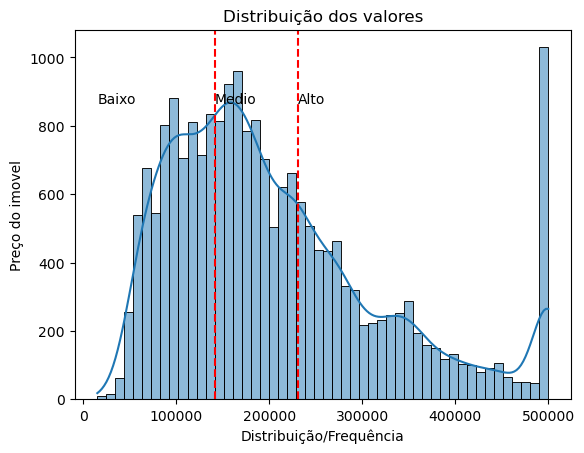

In [ ]:
#Plote um grafico com a distribuição dos valores
sns.histplot(df['valor_mediano_imoveis'], bins=50, kde=True)

#Linhas de cortes
plt.axvline(bins[1], linestyle='--', color='red')
plt.axvline(bins[2], linestyle='--', color='red')

#Texto (Baixo, medio, alto)
y_max = plt.gca().get_ylim()[1]

plt.text(bins[0], y_max * 0.8, 'Baixo')
plt.text(bins[1], y_max * 0.8, 'Medio')
plt.text(bins[2], y_max * 0.8, 'Alto')

#X, Y e titulo

plt.ylabel("Preço do imovel")
plt.xlabel("Distribuição/Frequência")
plt.title("Distribuição dos valores")

plt.show()

In [18]:
#Transformação de variaveis não numericas em numericas
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

df['proximidade_oceano'] = le.fit_transform(df['proximidade_oceano'])
df['valor_mediano_imoveis_categorico'] = le.fit_transform(df['valor_mediano_imoveis_categorico'])


In [20]:
#Separa as entradas e saída
x = df.drop(['valor_mediano_imoveis_categorico', 'valor_mediano_imoveis'], axis=1)
y = df['valor_mediano_imoveis_categorico']

In [21]:
#Preparação dos dados de treino e teste
from sklearn.model_selection import train_test_split

xtreino, xteste, ytreino, yteste = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
from xgboost import XGBRFClassifier

modelo_xgboost = XGBRFClassifier(n_estimators=100000000, max_depth = 10000, leaning_rate = 0.1, random_state = 42)
modelo_xgboost.fit(xtreino, ytreino)

In [25]:

from sklearn.metrics import accuracy_score, confusion_matrix

#Avaliação do modelo (MAPE E R2)

#Previsão para os dados de treino e teste
ypred_treino = modelo_xgboost.predict(xtreino)
ypred_teste = modelo_xgboost.predict(xteste)

#Métricas

print('Acuracia treino: ', accuracy_score(ytreino, ypred_treino))
print('Acuracia teste: ', accuracy_score(yteste, ypred_teste))

Acuracia treino:  0.719407530454042
Acuracia teste:  0.7078488372093024


In [ ]:
cm = confusion_matrix(yteste, ypred_teste)

plt.figure(figsize=(6,4))
sns.heatmap(cm, anoot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel('Real')

plt.title("Matriz de Confusão")
plt.show()